In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import dbof.dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.dataset_creation.zarr_grid_global    as zarr_grid
import dbof.io.filesystems as filesystems

# Assess GLOBAL dataset

This notebook inspects any subset written by `generate-global`.
Set `SUBSET` below to the subset you want to inspect.

All subsets from a session share the same `run_id` and live under the same
S3 directory with different zarr file names:
```
s3://{bucket}/{folder}/{run_id}/kinematic.zarr
s3://{bucket}/{folder}/{run_id}/frontogenesis.zarr
... etc.
```

| Subset | Stored channels (+ always-automatic `gradb2`) |
|---|---|
| `native_fields` | `Theta`, `Salt`, `Eta`, `U`, `V`, `W` |
| `frontal_structure` | `gradsalt2`, `gradtheta2`, `gradeta2`, `turner_angle` |
| `kinematic` | `relative_vorticity`, `strain_n`, `strain_s`, `strain_mag`, `divergence`, `coriolis_f`, `rossby_number`, `okubo_weiss` |
| `frontogenesis` | `frontogenesis_tendency`, `ug`, `vg`, `frontogenesis_geo`, `frontogenesis_ageo` |

## Dataset access config

Parameters are loaded from `configs/data_access/combined_global.yaml`.
Update `run_id` in that file to match the session you want to inspect.

Example config structure:
```yaml
data_access:
  s3_endpoint: "https://s3-west.nrp-nautilus.io"
  bucket: "dbof"
  folder: "native_grid_dbof_training_data"
  run_id: "global_20260317_120000"
  subsets:
    kinematic:
      dataset_name: "kinematic.zarr"
      feature_channels: [relative_vorticity, strain_n, ..., gradb2]
    ...
grid_access:
  ...
```

In [31]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS — choose which subset to inspect
# Options: 'native_fields' | 'frontal_structure' | 'kinematic' | 'frontogenesis' 
# ════════════════════════════════════════════════════════════════════════════════
SUBSET = 'frontogenesis'
# ════════════════════════════════════════════════════════════════════════════════

path_to_config = "../../configs/data_access/global.yaml"
with open(path_to_config) as f:
    cfg = yaml.safe_load(f)

data_cfg = cfg["data_access"]
grid_cfg = cfg["grid_access"]

# ── Shared fields ─────────────────────────────────────────────────────────────
bucket       = data_cfg["bucket"]
folder       = data_cfg["folder"]
s3_endpoint  = data_cfg["s3_endpoint"]
run_id       = data_cfg["run_id"]

# ── Subset-specific fields ────────────────────────────────────────────────────
subset_cfg      = data_cfg["subsets"][SUBSET]
dataset_name    = subset_cfg["dataset_name"]
feature_channels = subset_cfg["feature_channels"]

# ── Grid store ────────────────────────────────────────────────────────────────
grid_bucket       = grid_cfg["bucket"]
grid_folder       = grid_cfg["folder"]
grid_s3_endpoint  = grid_cfg["s3_endpoint"]
grid_dataset_name = grid_cfg["dataset_name"]

print(f"Subset   : {SUBSET}")
print(f"Snapshot : s3://{bucket}/{folder}/{run_id}/{dataset_name}")
print(f"Channels : {feature_channels}")
print(f"Grid     : s3://{grid_bucket}/{grid_folder}/{grid_dataset_name}")

Subset   : frontogenesis
Snapshot : s3://dbof/native_grid_dbof_training_data/global_20260318_052958/frontogenesis.zarr
Channels : ['frontogenesis_tendency', 'ug', 'vg', 'frontogenesis_geo', 'frontogenesis_ageo']
Grid     : s3://dbof/native_grid_dbof_training_data/llc4320_grid.zarr


# Load the data

In [32]:
# ── Snapshot reader ────────────────────────────────────────────────────────────
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name=dataset_name,
    fs=fs,
)
print(reader)
print(f"Channels : {reader.channel_names}")
print(f"Timesteps: {reader.n_timesteps}  |  shape: {reader.rectangular_shape}")

# ── Grid reader ────────────────────────────────────────────────────────────────
fs_grid, _ = filesystems.create_s3_filesystems(grid_s3_endpoint)

grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=grid_bucket,
    folder=grid_folder,
    dataset_name=grid_dataset_name,
    fs=fs_grid,
)
print(grid_reader)

# ── Load full-resolution lat/lon ───────────────────────────────────────────────
XC = grid_reader.lon   # (H, W) float32, degrees east
YC = grid_reader.lat   # (H, W) float32, degrees north
print(f"Grid loaded: XC {XC.shape}, lon [{XC.min():.1f}, {XC.max():.1f}]  "
      f"YC {YC.shape}, lat [{YC.min():.1f}, {YC.max():.1f}]")

# ── Precompute downsampled coords for fast global plotting ─────────────────────
DS_GLOBAL = 20   # 20× downsample → (648, 864) per field
XC_g = XC[::DS_GLOBAL, ::DS_GLOBAL]
YC_g = YC[::DS_GLOBAL, ::DS_GLOBAL]

Channels : ['frontogenesis_tendency', 'ug', 'vg', 'frontogenesis_geo', 'frontogenesis_ageo']
Timesteps: 1  |  shape: (12960, 17280)
GlobalGridZarrReader(shape=(12960, 17280), variables=['XC', 'YC', 'rA', 'Depth', 'SN', 'CS', 'hFacC', 'dxC', 'dyG', 'hFacW', 'rAw', 'dyC', 'dxG', 'hFacS', 'rAs', 'rAz', 'XG', 'YG', 'lat', 'lon'])
Grid loaded: XC (12960, 17280), lon [-180.0, 180.0]  YC (12960, 17280), lat [-90.0, 72.0]


In [33]:
print(f"n_timesteps: {reader.n_timesteps}")
print(f"time array:  {reader.time[:]}")

n_timesteps: 1
time array:  [1463616]


# Colormap / label configuration

All channels across all subsets are registered here.  Only the channels
present in the selected subset will be plotted.

In [34]:
# ── Colormap and physical label for every possible channel ────────────────────
# cmo colormaps: https://matplotlib.org/cmocean/
CMAP_CFG = {
    # native_fields
    'Theta':                  ('thermal', 'Temperature (°C)'),
    'Salt':                   ('haline',  'Salinity (psu)'),
    'Eta':                    ('gray',    r'$\eta$ (m)'),
    'U':                      ('balance', 'U velocity (m s⁻¹)'),
    'V':                      ('balance', 'V velocity (m s⁻¹)'),
    'W':                      ('balance', 'W velocity (m s⁻¹)'),
    # frontal_structure
    'gradsalt2':              ('haline',  r'$|\nabla S|^2$ (psu² m⁻²)'),
    'gradtheta2':             ('thermal', r'$|\nabla\Theta|^2$ (°C² m⁻²)'),
    'gradeta2':               ('gray',    r'$|\nabla\eta|^2$ (m² m⁻²)'),
    'gradb2':                 ('tempo',   r'$|\nabla b|^2$ (s⁻⁴)'),
    # kinematic
    'relative_vorticity':     ('diff',    'Rel. vorticity (s⁻¹)'),
    'strain_n':               ('diff',    'Normal strain (s⁻¹)'),
    'strain_s':               ('diff',    'Shear strain (s⁻¹)'),
    'strain_mag':             ('amp',     'Strain magnitude (s⁻¹)'),
    'divergence':             ('diff',    'Divergence (s⁻¹)'),
    'coriolis_f':             ('delta',   'Coriolis f (s⁻¹)'),
    'rossby_number':          ('diff',    'Rossby number'),
    'okubo_weiss':            ('diff',    'Okubo-Weiss (s⁻²)'),
    # dynamical
    'frontogenesis_tendency': ('diff',    r'$F_{\rm strain}$ (s⁻⁵)'),
    # geostrophic
    'ug':                     ('balance', r'$u_g$ (m s⁻¹)'),
    'vg':                     ('balance', r'$v_g$ (m s⁻¹)'),
    'frontogenesis_geo':      ('diff',    r'$F_{\rm geo}$ (s⁻⁵)'),
    'frontogenesis_ageo':     ('diff',    r'$F_{\rm ageo}$ (s⁻⁵)'),
}

# Channels to plot: only those stored in this subset
channels_to_plot = [ch for ch in reader.channel_names if ch in CMAP_CFG]
print(f"Plotting {len(channels_to_plot)} channels: {channels_to_plot}")

Plotting 5 channels: ['frontogenesis_tendency', 'ug', 'vg', 'frontogenesis_geo', 'frontogenesis_ageo']


## Single-channel global map

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


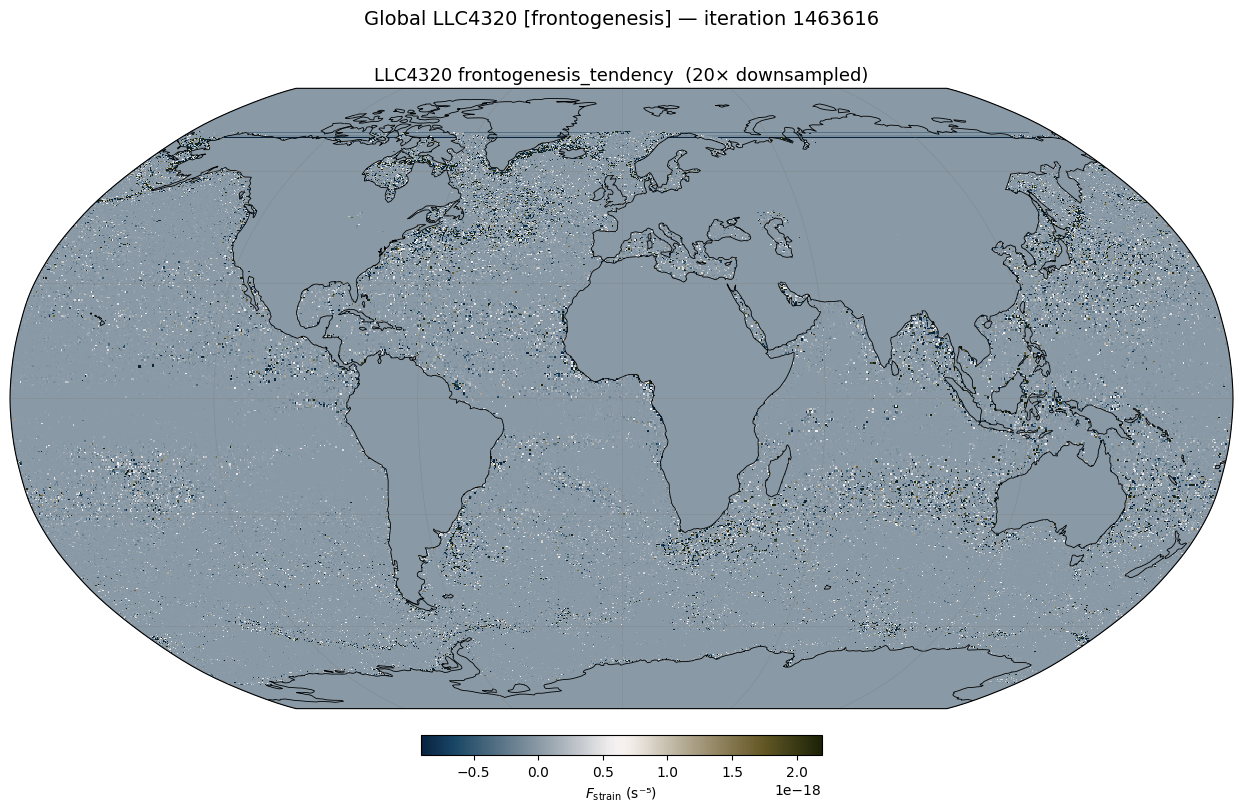

In [35]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
target    = channels_to_plot[0]   # change to any channel in channels_to_plot
timestep  = 0                     # timestep index
# ════════════════════════════════════════════════════════════════════════════════

arr_ds = reader.get_channel_snapshot(timestep, target)[::DS_GLOBAL, ::DS_GLOBAL]
cmap_name, label = CMAP_CFG[target]
cmap = getattr(cmo, cmap_name)
finite = arr_ds[np.isfinite(arr_ds)]
vmin, vmax = np.nanpercentile(finite, [1, 99])

fig = plt.figure(figsize=(16, 8))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

im = ax.pcolormesh(XC_g, YC_g, arr_ds,
                   cmap=cmap, vmin=vmin, vmax=vmax,
                   transform=ccrs.PlateCarree(),
                   shading='nearest')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='k')
ax.gridlines(linewidth=0.4, color='gray', alpha=0.6)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, shrink=0.7,
             label=label, orientation='horizontal')
ax.set_title(f'LLC4320 {target}  ({DS_GLOBAL}× downsampled)', fontsize=13)
plt.suptitle(f'Global LLC4320 [{SUBSET}] — iteration {reader.time[timestep]}',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## All-channels global overview

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/lhoffma2/miniforge

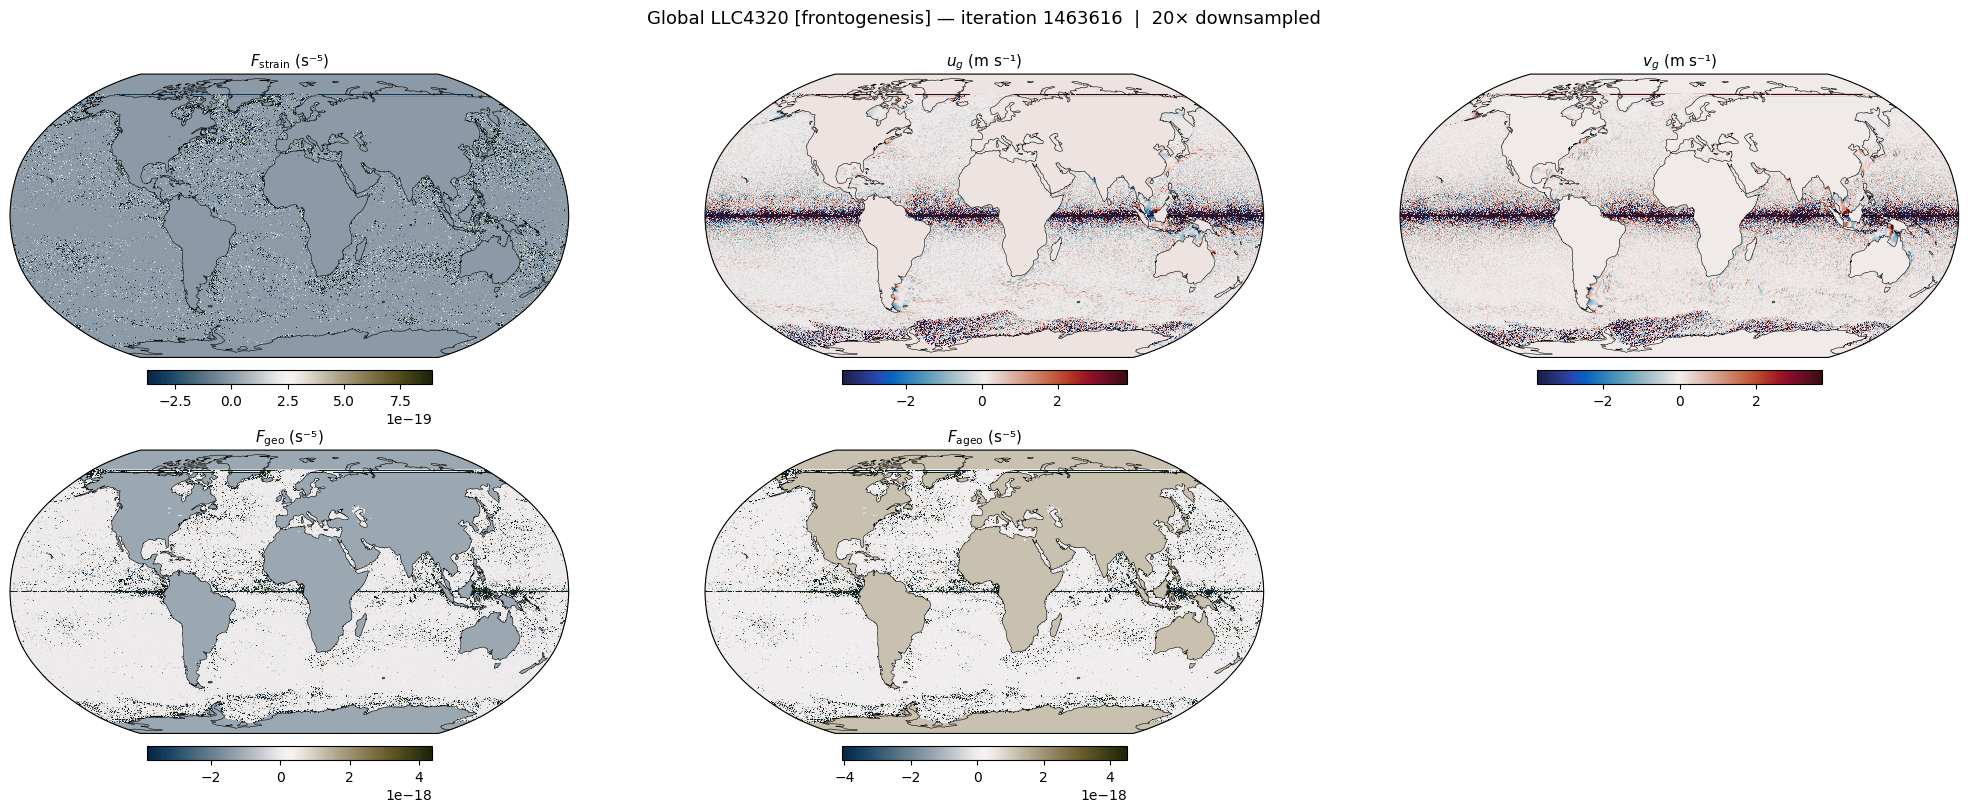

In [36]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
timestep = 0
ncols    = 3   # adjust to taste
# ════════════════════════════════════════════════════════════════════════════════

nrows = int(np.ceil(len(channels_to_plot) / ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 7, nrows * 4),
    subplot_kw={'projection': ccrs.Robinson()},
)
axes = np.array(axes).flatten()

for ax, ch in zip(axes, channels_to_plot):
    arr = reader.get_channel_snapshot(timestep, ch)[::DS_GLOBAL, ::DS_GLOBAL]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmin, vmax = np.nanpercentile(finite, [2, 98])
    im = ax.pcolormesh(XC_g, YC_g, arr,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(),
                       shading='nearest')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k')
    ax.set_title(label, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85,
                 orientation='horizontal')

for ax in axes[len(channels_to_plot):]:
    ax.set_visible(False)

plt.suptitle(
    f'Global LLC4320 [{SUBSET}] — iteration {reader.time[timestep]}  |  {DS_GLOBAL}× downsampled',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## Regional plots

### Region selection by lat/lon

The grid (XC, YC) is loaded — you can select any region by geographic
coordinates.  The nearest pixel to your requested **(lat, lon)** centre is
found automatically, and the bounding box is derived from an approximate
km-to-pixel conversion (LLC4320 native resolution ≈ 1/48° ≈ 2.3 km at
mid-latitudes).

In [37]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS — edit these to choose your region
# ════════════════════════════════════════════════════════════════════════════════
LAT_CENTER = 36.0       # degrees north
LON_CENTER = -72.0      # degrees east  (use negative for west)
HALF_H_KM  = 1000.0     # approximate half-height of region (km)
HALF_W_KM  = 2000.0     # approximate half-width  of region (km)
# ════════════════════════════════════════════════════════════════════════════════

H, W = reader.rectangular_shape

# Normalise requested longitude to match XC convention
lon_q = LON_CENTER % 360 if float(XC.max()) > 180 else LON_CENTER

# Find nearest pixel to (LAT_CENTER, lon_q)
dist = np.sqrt((XC - lon_q) ** 2 + (YC - LAT_CENTER) ** 2)
cy, cx = np.unravel_index(int(np.nanargmin(dist)), dist.shape)
print(f"Nearest pixel to ({LAT_CENTER}°N, {LON_CENTER}°E): y={cy}, x={cx}  "
      f"[actual: lat={YC[cy,cx]:.3f}°N, lon={XC[cy,cx]:.3f}°E]")

# Convert km → pixels  (LLC4320 ≈ 1/48° ≈ 2.3 km at mid-latitudes)
KM_PER_PIX = 2.3
HALF_H_PIX = int(HALF_H_KM / KM_PER_PIX)
HALF_W_PIX = int(HALF_W_KM / KM_PER_PIX)

# Clamp to image extent
y0 = max(0, cy - HALF_H_PIX)
y1 = min(H, cy + HALF_H_PIX)
x0 = max(0, cx - HALF_W_PIX)
x1 = min(W, cx + HALF_W_PIX)

XC_reg = XC[y0:y1, x0:x1]
YC_reg = YC[y0:y1, x0:x1]

print(f"Region: rows [{y0}:{y1}], cols [{x0}:{x1}]  →  {y1-y0} × {x1-x0} pixels")
print(f"Geographic extent: lon [{float(XC_reg.min()):.2f}, {float(XC_reg.max()):.2f}]  "
      f"lat [{float(YC_reg.min()):.2f}, {float(YC_reg.max()):.2f}]")

Nearest pixel to (36.0°N, -72.0°E): y=9931, x=15647  [actual: lat=35.996°N, lon=-72.010°E]
Region: rows [9497:10365], cols [14778:16516]  →  868 × 1738 pixels
Geographic extent: lon [-90.11, -53.93]  lat [28.98, 42.46]


/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


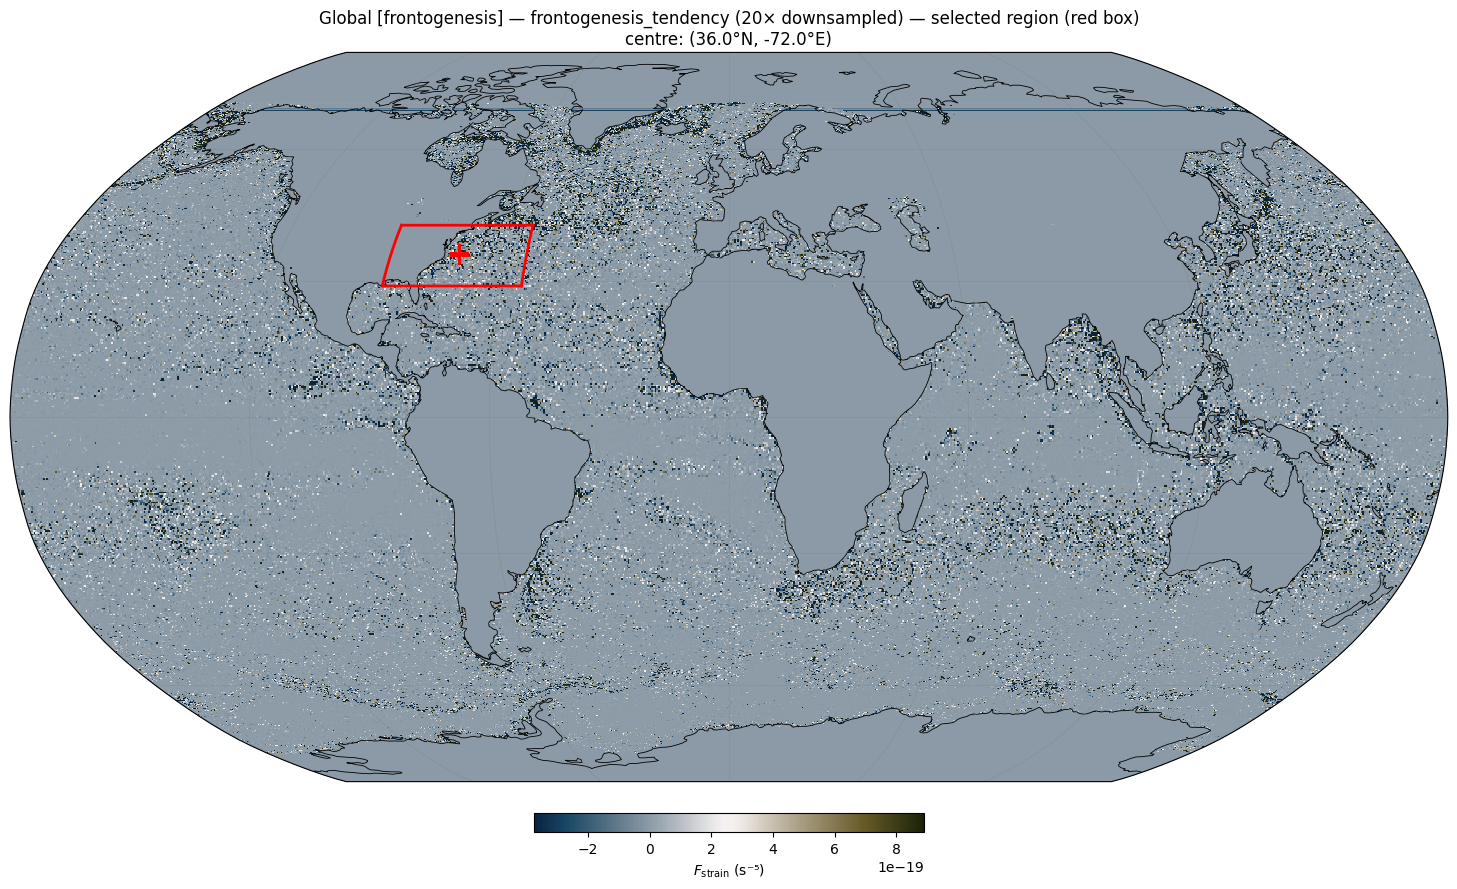

In [38]:
# ── Global context map with selected region outlined ──────────────────────────
# Uses the first channel in the subset as background context.
context_ch = channels_to_plot[0]
ctx_ds = reader.get_channel_snapshot(0, context_ch)[::DS_GLOBAL, ::DS_GLOBAL]
ctx_cmap_name, ctx_label = CMAP_CFG[context_ch]
vmin_c, vmax_c = np.nanpercentile(ctx_ds[np.isfinite(ctx_ds)], [2, 98])

fig = plt.figure(figsize=(18, 9))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

im = ax.pcolormesh(XC_g, YC_g, ctx_ds,
                   cmap=getattr(cmo, ctx_cmap_name), vmin=vmin_c, vmax=vmax_c,
                   transform=ccrs.PlateCarree(), shading='nearest')
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04, shrink=0.7,
             label=ctx_label, orientation='horizontal')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='k')
ax.gridlines(linewidth=0.4, color='gray', alpha=0.5)

# Draw the selection box
pc = ccrs.PlateCarree()
ax.plot(XC[y0, x0:x1],   YC[y0, x0:x1],   'r-', lw=2, transform=pc)
ax.plot(XC[y1-1, x0:x1], YC[y1-1, x0:x1], 'r-', lw=2, transform=pc)
ax.plot(XC[y0:y1, x0],   YC[y0:y1, x0],   'r-', lw=2, transform=pc)
ax.plot(XC[y0:y1, x1-1], YC[y0:y1, x1-1], 'r-', lw=2, transform=pc)
ax.plot(float(XC[cy, cx]), float(YC[cy, cx]),
        'r+', markersize=14, markeredgewidth=2.5, transform=pc, zorder=6)

ax.set_title(
    f'Global [{SUBSET}] — {context_ch} ({DS_GLOBAL}× downsampled) — selected region (red box)\n'
    f'centre: ({LAT_CENTER}°N, {LON_CENTER}°E)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

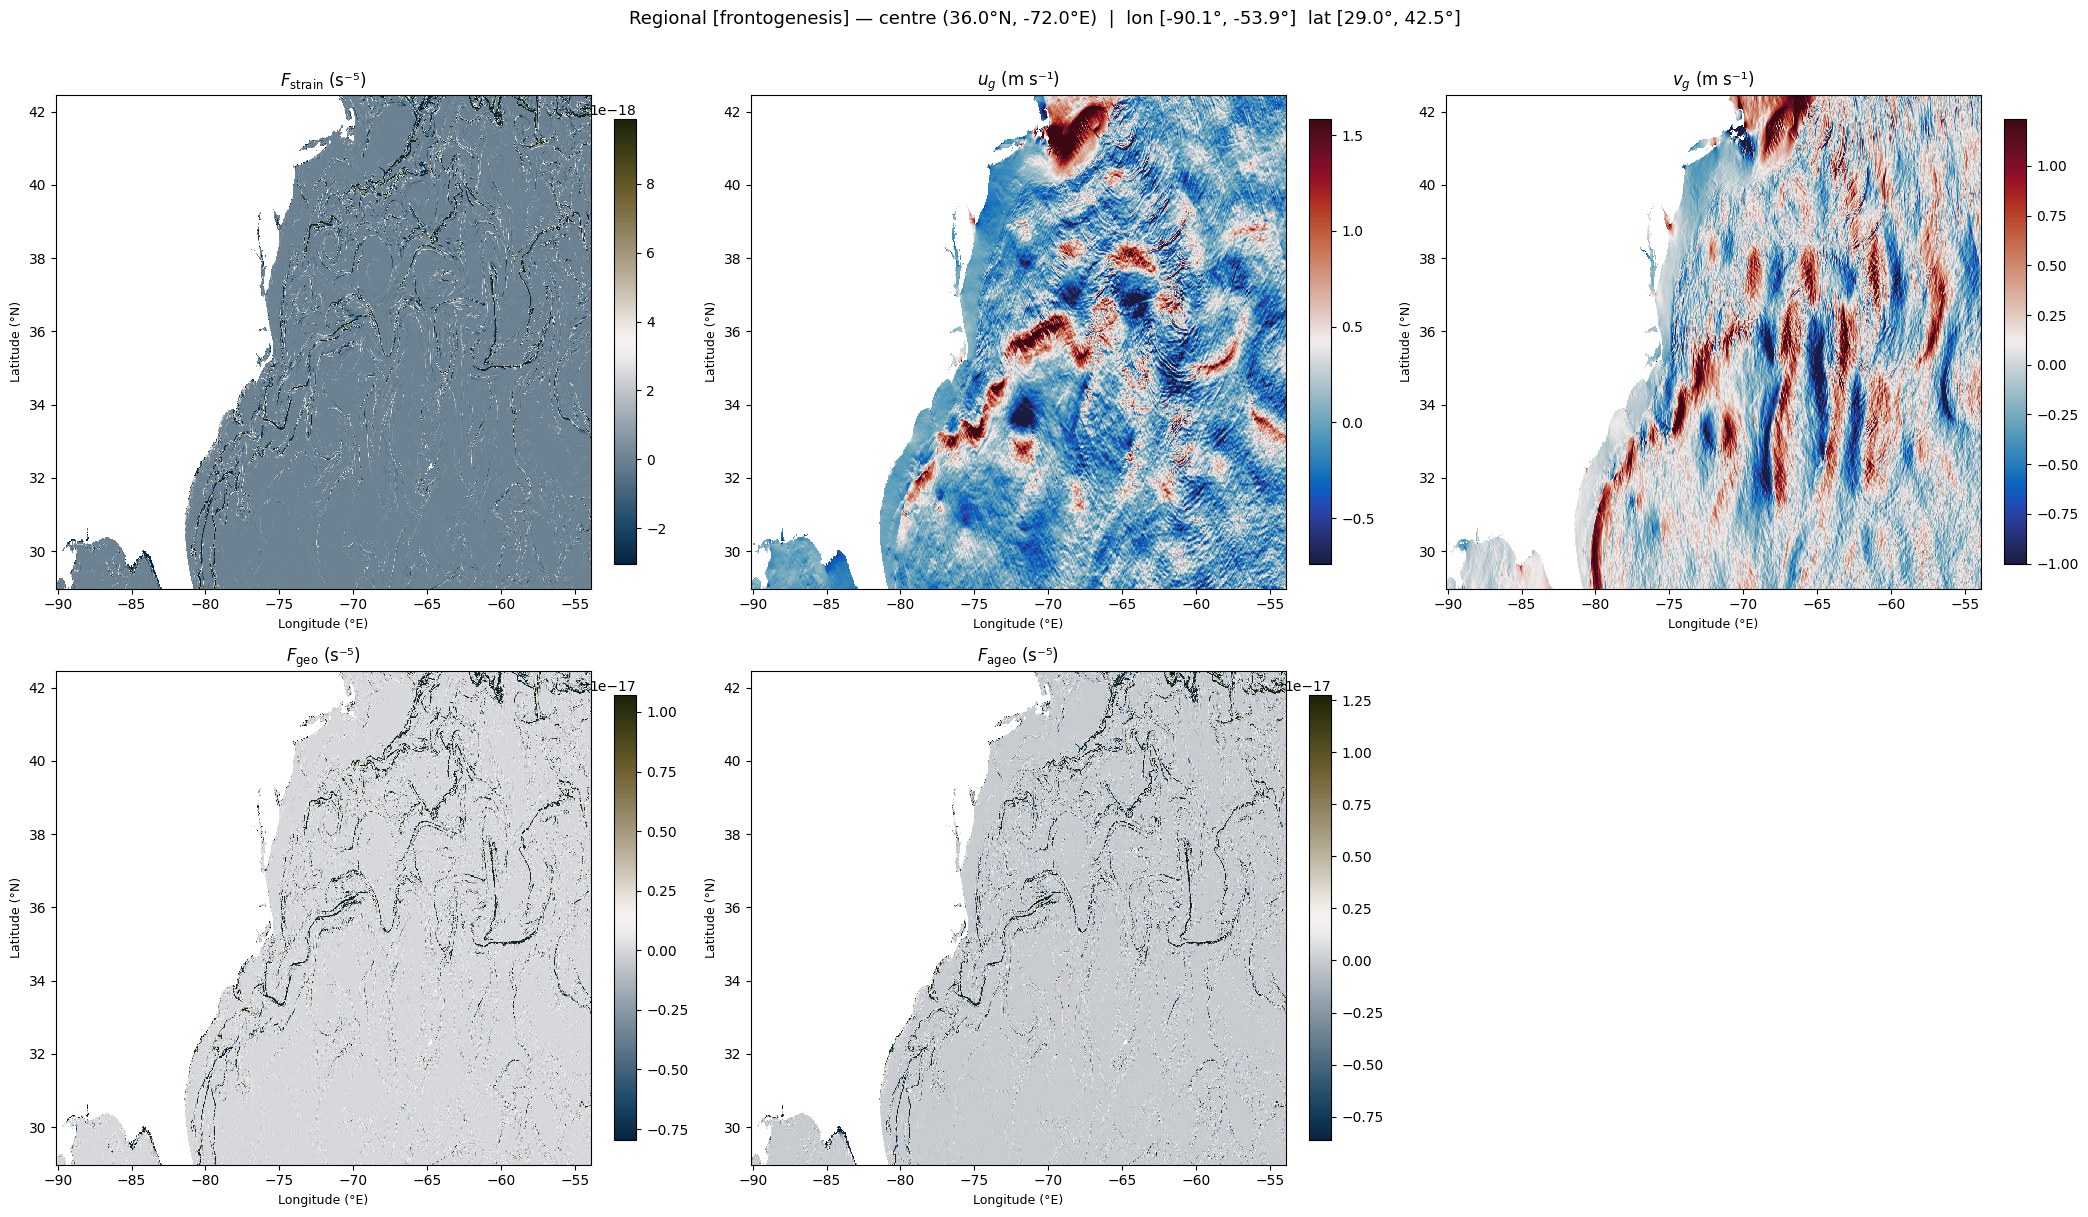

In [39]:
# ── Regional subplots — actual lat/lon from grid ───────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
timestep = 0
ncols    = 3   # adjust to taste
# ════════════════════════════════════════════════════════════════════════════════

nrows = int(np.ceil(len(channels_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 6))
axes = np.array(axes).flatten()

for ax, ch in zip(axes, channels_to_plot):
    arr = reader.get_channel_snapshot(timestep, ch)[y0:y1, x0:x1]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmin, vmax = np.nanpercentile(finite, [1, 99])
    im = ax.pcolormesh(XC_reg, YC_reg, arr,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       shading='nearest')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Longitude (°E)', fontsize=9)
    ax.set_ylabel('Latitude (°N)',  fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9)

for ax in axes[len(channels_to_plot):]:
    ax.set_visible(False)

plt.suptitle(
    f'Regional [{SUBSET}] — centre ({LAT_CENTER}°N, {LON_CENTER}°E)  |  '
    f'lon [{float(XC_reg.min()):.1f}°, {float(XC_reg.max()):.1f}°]  '
    f'lat [{float(YC_reg.min()):.1f}°, {float(YC_reg.max()):.1f}°]',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()